In [1]:
# Import of all libraries
from nasbench import api # Usage of nasbench API
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import copy
import random
import math

In [2]:
nasbench = api.NASBench('nasbench_only108.tfrecord')
# nasbench = api.NASBench('nasbench_full.tfrecord')

Loading dataset from file... This may take a few minutes...
Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`
Loaded dataset in 33 seconds


In [3]:
# Definition of the task, inspired by nasbench: https://github.com/google-research/nasbench/blob/master/NASBench.ipynb
# Useful constants
INPUT = 'input'
OUTPUT = 'output'
CONV3X3 = 'conv3x3-bn-relu'
CONV1X1 = 'conv1x1-bn-relu'
MAXPOOL3X3 = 'maxpool3x3'
NUM_VERTICES = 7
MAX_EDGES = 9
EDGE_SPOTS = NUM_VERTICES * (NUM_VERTICES - 1) / 2   # Upper triangular matrix
OP_SPOTS = NUM_VERTICES - 2   # Input/output vertices are fixed
ALLOWED_OPS = [CONV3X3, CONV1X1, MAXPOOL3X3]
ALLOWED_EDGES = [0, 1]   # Binary adjacency matrix

In [4]:
# Definition of the task, inspired by nasbench: https://github.com/google-research/nasbench/blob/master/NASBench.ipynb
# Query an Inception-like cell from the dataset.
cell = api.ModelSpec(
  matrix=[[0, 1, 1, 1, 0, 1, 0],    # input layer
          [0, 0, 0, 0, 0, 0, 1],    # 1x1 conv
          [0, 0, 0, 0, 0, 0, 1],    # 3x3 conv
          [0, 0, 0, 0, 1, 0, 0],    # 5x5 conv (replaced by two 3x3's)
          [0, 0, 0, 0, 0, 0, 1],    # 5x5 conv (replaced by two 3x3's)
          [0, 0, 0, 0, 0, 0, 1],    # 3x3 max-pool
          [0, 0, 0, 0, 0, 0, 0]],   # output layer
  # Operations at the vertices of the module, matches order of matrix.
  ops=[INPUT, CONV1X1, CONV3X3, CONV3X3, CONV3X3, MAXPOOL3X3, OUTPUT])

# Querying multiple times may yield different results. Each cell is evaluated 3
# times at each epoch budget and querying will sample one randomly.
data = nasbench.query(cell)
for k, v in data.items():
  print('%s: %s' % (k, str(v)))

module_adjacency: [[0 1 1 1 1 0 0]
 [0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1]
 [0 0 0 0 0 1 0]
 [0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0]]
module_operations: ['input', 'conv3x3-bn-relu', 'conv1x1-bn-relu', 'maxpool3x3', 'conv3x3-bn-relu', 'conv3x3-bn-relu', 'output']
trainable_parameters: 2694282
training_time: 1155.85302734375
train_accuracy: 1.0
validation_accuracy: 0.9376001358032227
test_accuracy: 0.9311898946762085


In [5]:
# From nasbench: https://github.com/google-research/nasbench/blob/master/NASBench.ipynb
def random_spec():
  """Returns a random valid spec."""
  while True:
    matrix = np.random.choice(ALLOWED_EDGES, size=(NUM_VERTICES, NUM_VERTICES))
    matrix = np.triu(matrix, 1)
    ops = np.random.choice(ALLOWED_OPS, size=(NUM_VERTICES)).tolist()
    ops[0] = INPUT
    ops[-1] = OUTPUT
    spec = api.ModelSpec(matrix=matrix, ops=ops)
    if nasbench.is_valid(spec):
      return spec

def mutate_spec(old_spec, mutation_rate=1.0):
  """Computes a valid mutated spec from the old_spec."""
  while True:
    new_matrix = copy.deepcopy(old_spec.original_matrix)
    new_ops = copy.deepcopy(old_spec.original_ops)
    edge_mutation_prob = mutation_rate / NUM_VERTICES
    for src in range(0, NUM_VERTICES - 1):
      for dst in range(src + 1, NUM_VERTICES):
        if random.random() < edge_mutation_prob:
          new_matrix[src, dst] = 1 - new_matrix[src, dst]
    
    op_mutation_prob = mutation_rate / OP_SPOTS
    for ind in range(1, NUM_VERTICES - 1):
      if random.random() < op_mutation_prob:
        available = [o for o in nasbench.config['available_ops'] if o != new_ops[ind]]
        new_ops[ind] = random.choice(available)
        
    new_spec = api.ModelSpec(new_matrix, new_ops)
    if nasbench.is_valid(new_spec):
      return new_spec

def random_combination(iterable, sample_size):
  """Random selection from itertools.combinations(iterable, r)."""
  pool = tuple(iterable)
  n = len(pool)
  indices = sorted(random.sample(range(n), sample_size))
  return tuple(pool[i] for i in indices)

def run_random_search(max_time_budget=10e6):
  """Run a single roll-out of random search to a fixed time budget."""
  nasbench.reset_budget_counters()
  times, best_valids, best_tests = [0.0], [0.0], [0.0]
  while True:
    spec = random_spec()
    data = nasbench.query(spec)

    # It's important to select models only based on validation accuracy, test
    # accuracy is used only for comparing different search trajectories.
    if data['training_time'] > best_valids[-1]:
      best_valids.append(data['training_time'])
      best_tests.append(data['test_accuracy'])
    else:
      best_valids.append(best_valids[-1])
      best_tests.append(best_tests[-1])

    time_spent, _ = nasbench.get_budget_counters()
    times.append(time_spent)
    if time_spent > max_time_budget:
      # Break the first time we exceed the budget.
      break

  return times, best_valids, best_tests

def run_evolution_search(max_time_budget=10e6,
                         population_size=100,
                         tournament_size=10,
                         mutation_rate=1.0):
  """Run a single roll-out of regularized evolution to a fixed time budget."""
  nasbench.reset_budget_counters()
  times, best_valids, best_tests = [0.0], [0.0], [0.0]
  population = []   # (validation, spec) tuples

  # For the first population_size individuals, seed the population with randomly
  # generated cells.
  for _ in range(population_size):
    spec = random_spec()
    data = nasbench.query(spec)

    time_spent, _ = nasbench.get_budget_counters()
    times.append(time_spent)
    population.append((data['training_time'], spec))

    if data['training_time'] > best_valids[-1]:
      best_valids.append(data['training_time'])
      best_tests.append(data['test_accuracy'])
    else:
      best_valids.append(best_valids[-1])
      best_tests.append(best_tests[-1])

    if time_spent > max_time_budget:
      break

  # After the population is seeded, proceed with evolving the population.
  while True:
    sample = random_combination(population, tournament_size)
    best_spec = sorted(sample, key=lambda i:i[0])[-1][1]
    new_spec = mutate_spec(best_spec, mutation_rate)

    data = nasbench.query(new_spec)

    time_spent, _ = nasbench.get_budget_counters()
    times.append(time_spent)

    # In regularized evolution, we kill the oldest individual in the population.
    # pre regularized
    population.append((data['training_time'], new_spec))
    population.pop(0)

    if data['training_time'] > best_valids[-1]:
      best_valids.append(data['training_time'])
      best_tests.append(data['test_accuracy'])
    else:
      best_valids.append(best_valids[-1])
      best_tests.append(best_tests[-1])

    if time_spent > max_time_budget:
      break

  return times, best_valids, best_tests
  

In [6]:
# In this cell there is the implementation of more classical GA
# Unlike nasbench evolution it uses crossover function
def crossover(parent1, parent2):
    """Combine two specs by merging their edges and operations."""
    # Merge adjacency matrices
    matrix_shape = parent1.original_matrix.shape # Dimension of the matrix
    mask = np.random.rand(*matrix_shape) # random matrix of same shape
    
    # Choose parents1 value if random > 0.5, else parents2
    new_matrix = np.where(mask > 0.5, parent1.original_matrix, parent2.original_matrix)
    
    # Merge operations
    new_ops = []
    for p1_op, p2_op in zip(parent1.original_ops, parent2.original_ops):
        if random.random() > 0.5:
            new_ops.append(p1_op)
        else:
            new_ops.append(p2_op)
    
    # Get all metrics from dataset for this new CNN
    new_spec = api.ModelSpec(new_matrix, new_ops)
    
    if nasbench.is_valid(new_spec):
        return new_spec
    else:
        return parent1


def run_GA(max_time_budget=10e6,
           population_size=100,
           mutation_rate=1.0,
           tournament_size=3,
           crossover_rate=0.8,
           elitism=5           #To preserve 5 best into new population
          ):
    """ Runs GA with crossover to a fixed time budget """
    nasbench.reset_budget_counters()
    times, best_valids, best_tests = [0.0], [0.0], [0.0]
    population = []  # List of (training_time, spec) tuples


    # Initial population seeding
    for _ in range(population_size):
        spec = random_spec()
        data = nasbench.query(spec)
        fitness = data['training_time']
        
        time_spent, _ = nasbench.get_budget_counters()
        times.append(time_spent)
        population.append((fitness, spec))
        
        # Update best accuracies
        if fitness > best_valids[-1]:
            best_valids.append(fitness)
            best_tests.append(data['test_accuracy'])
        else:
            best_valids.append(best_valids[-1])
            best_tests.append(best_tests[-1])
        
        if time_spent > max_time_budget:
            break

    # Evolution loop
    while True:
        new_population = []
        
        # Keep 5 best to new population
        best_5 = sorted(population, key=lambda x: x[0], reverse=True)[:elitism]
        new_population.extend(best_5)
        
        for _ in range(population_size - elitism):
            # Reproduction
            if random.random() < crossover_rate and len(population) >= 2:
                # Crossover - Select two parents and combine
                parent1 = max(random.sample(population, tournament_size), key=lambda x: x[0])[1]
                parent2 = max(random.sample(population, tournament_size), key=lambda x: x[0])[1]
                child_spec = crossover(parent1, parent2)
            else:
                # Mutation-only path
                parent = max(random.sample(population, tournament_size), key=lambda x: x[0])[1]
                child_spec = mutate_spec(parent) if random.random() < mutation_rate else parent
            
            # Evaluate child
            data = nasbench.query(child_spec)
            child_fitness = data['training_time']
            time_spent, _ = nasbench.get_budget_counters()
            times.append(time_spent)
            
            new_population.append((child_fitness, child_spec))
            
            # Update best accuracies
            if child_fitness > best_valids[-1]:
                best_valids.append(child_fitness)
                best_tests.append(data['test_accuracy'])
            else:
                best_valids.append(best_valids[-1])
                best_tests.append(best_tests[-1])
            
            if time_spent > max_time_budget:
                break
        
        population = new_population
        time_spent, _ = nasbench.get_budget_counters()
        if time_spent > max_time_budget:
            break

    return times, best_valids, best_tests

In [7]:
# Last implemented search algorithm for comparision between each other
def run_simulated_annealing(max_time_budget=10e6):
    """Simulated Annealing with similar structure as previous algorithms"""
    nasbench.reset_budget_counters()
    times, best_valids, best_tests = [0.0], [0.0], [0.0]
    
    # SA parameters
    temperature = 100.0
    cooling_rate = 0.95
    spec = random_spec()
    data = nasbench.query(spec)
    fitness = data['training_time']
    
    while True:
        # Generate neighbor
        neighbor = mutate_spec(spec)
        neighbor_data = nasbench.query(neighbor)
        
        # Acceptance probability
        delta = neighbor_data['training_time'] - fitness
        if delta > 0 or random.random() < math.exp(delta / temperature):
            spec = neighbor
            fitness = neighbor_data['training_time']
        
        temperature *= cooling_rate
        
        if fitness > best_valids[-1]:
            best_valids.append(fitness)
            best_tests.append(neighbor_data['test_accuracy'])
        else:
            best_valids.append(best_valids[-1])
            best_tests.append(best_tests[-1])
        
        time_spent, _ = nasbench.get_budget_counters()
        times.append(time_spent)
        if time_spent > max_time_budget:
            break
    
    return times, best_valids, best_tests

In [8]:
# Inspired by nasbench: https://github.com/google-research/nasbench/blob/master/NASBench.ipynb
random_data = []
evolution_data_regul = []
evolution_data_cross = []
simulated_data = []
for repeat in range(10):
  print('Running repeat %d' % (repeat + 1))
  times, best_valid, best_test = run_random_search()
  random_data.append((times, best_valid, best_test))

  times, best_valid, best_test = run_evolution_search()
  evolution_data_regul.append((times, best_valid, best_test))

  times, best_valid, best_test = run_GA()
  evolution_data_cross.append((times, best_valid, best_test))

  times, best_valid, best_test = run_simulated_annealing()
  simulated_data.append((times, best_valid, best_test))

Running repeat 1
Running repeat 2
Running repeat 3
Running repeat 4
Running repeat 5
Running repeat 6
Running repeat 7
Running repeat 8
Running repeat 9
Running repeat 10


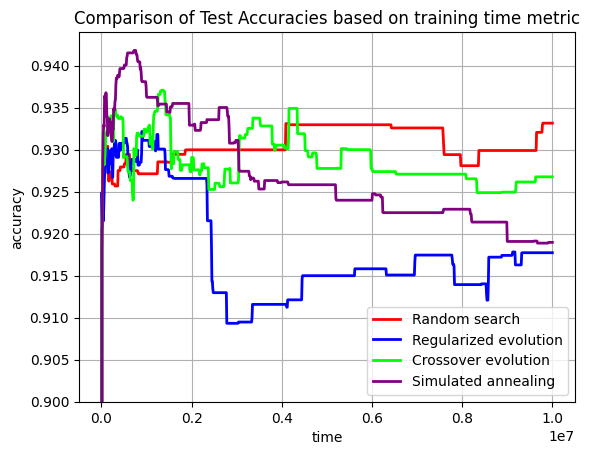

In [9]:
# Inspired by nasbench: https://github.com/google-research/nasbench/blob/master/NASBench.ipynb
# Compare the mean accuracy
def plot_data(data, color, label, gran=10000, max_budget=10000000):
  """Computes the mean for each algorithm"""
  xs = range(0, max_budget+1, gran)
  mean = [0.0]
  
  repeats = len(data)
  pointers = [1 for _ in range(repeats)]
  
  cur = gran
  while cur < max_budget+1:
    all_vals = []
    for repeat in range(repeats):
      while (pointers[repeat] < len(data[repeat][0]) and 
             data[repeat][0][pointers[repeat]] < cur):
        pointers[repeat] += 1
      prev_time = data[repeat][0][pointers[repeat]-1]
      prev_test = data[repeat][2][pointers[repeat]-1]
      next_time = data[repeat][0][pointers[repeat]]
      next_test = data[repeat][2][pointers[repeat]]
      assert prev_time < cur and next_time >= cur

      # Linearly interpolate the test between the two surrounding points
      cur_val = ((cur - prev_time) / (next_time - prev_time)) * (next_test - prev_test) + prev_test
      
      all_vals.append(cur_val)
      
    all_vals = sorted(all_vals)
    mean.append(sum(all_vals) / float(len(all_vals)))
      
    cur += gran
    
  plt.plot(xs, mean, color=color, label=label, linewidth=2)

plot_data(random_data, 'red', 'Random search')
plot_data(evolution_data_regul, 'blue', 'Regularized evolution')
plot_data(evolution_data_cross, 'lime', 'Crossover evolution')
plot_data(simulated_data, 'purple', 'Simulated annealing')
plt.legend(loc='lower right')
plt.ylim(0.9, 0.944)
plt.xlabel('time')
plt.ylabel('accuracy')
plt.title('Comparison of Test Accuracies based on training time metric')
plt.grid()

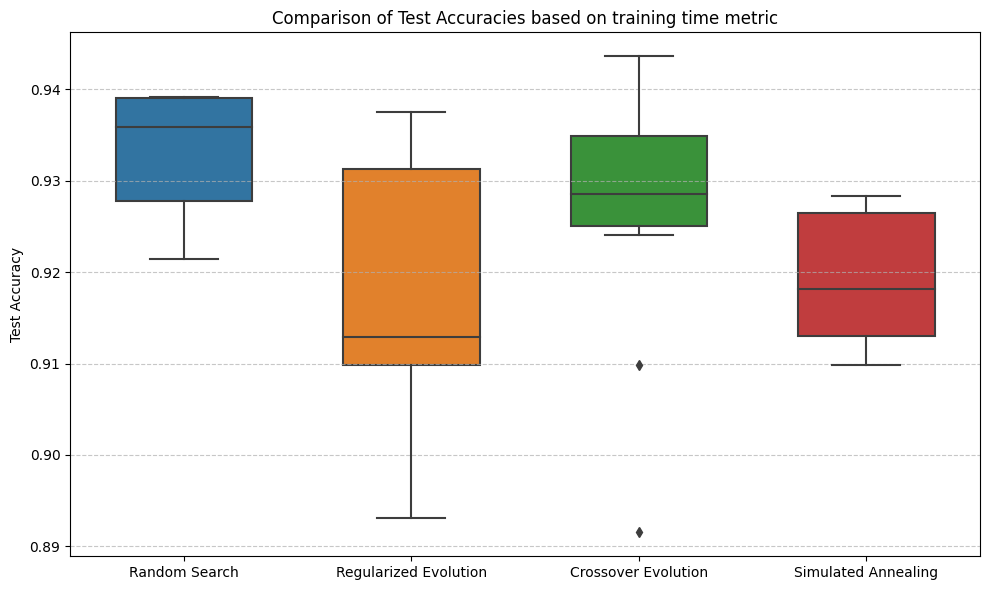

In [10]:
# Box plot graph
plt.figure(figsize=(10, 6))

# Prepare data
random_acc = [run[2][-1] for run in random_data]
evolution_acc = [run[2][-1] for run in evolution_data_regul]
evolution_cross_acc = [run[2][-1] for run in evolution_data_cross]
simulated_acc = [run[2][-1] for run in simulated_data]

# Create boxplot
boxplot_data = [random_acc, evolution_acc, evolution_cross_acc, simulated_acc]
labels = ['Random Search', 'Regularized Evolution', 'Crossover Evolution', 'Simulated Annealing']

sns.boxplot(data=boxplot_data, width=0.6)

# Set x-ticks
plt.xticks([0, 1, 2, 3], labels)
plt.ylabel('Test Accuracy')
plt.title('Comparison of Test Accuracies based on training time metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()